In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings

# Ignore warnings to keep the notebook clean
warnings.filterwarnings('ignore')

# Load the prepared dataset
df_ml = pd.read_csv('../data/processed/berlin_airbnb_cleaned_ML.csv')

print(f"Dataset loaded successfully! Shape: {df_ml.shape}")

Dataset loaded successfully! Shape: (4999, 2370)


In [8]:
# 1. Separate features (X) and target variable (y)
X = df_ml.drop(columns=['Price'])
y = df_ml['Price']

# 2. Split the dataset into training set (80%) and testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

(3999, 2369) (1000, 2369)
Training features shape: (3999, 2369)
Testing features shape: (1000, 2369)
Training target shape: (3999,)
Testing target shape: (1000,)


In [9]:
# 1. Initialize the Linear Regression model
lr_model = LinearRegression()

# 2. Train the model using the training data
lr_model.fit(X_train, y_train)

# 3. Make predictions on the test data
y_pred = lr_model.predict(X_test)

print("Model training complete! Predictions have been generated.")

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [10]:
# تنظيف البيانات من أي قيم فارغة متبقية
from sklearn.impute import SimpleImputer

# إنشاء أداة لملء الفراغات بالمتوسط (Median)
imputer = SimpleImputer(strategy='median')

# تطبيق التنظيف على بيانات التدريب والاختبار
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# الآن استخدمي البيانات المنظفة في التدريب
lr_model.fit(X_train_imputed, y_train)

# والتنبؤ
y_pred = lr_model.predict(X_test_imputed)

print("تم تدريب النموذج بنجاح بعد معالجة القيم المفقودة!")

تم تدريب النموذج بنجاح بعد معالجة القيم المفقودة!


In [11]:
# 1. Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# 2. Print the results clearly
print("====================================")
print("   LINEAR REGRESSION EVALUATION     ")
print("====================================")
print(f"R-squared (R2) Score : {r2:.4f} ({r2*100:.2f}%)")
print(f"Mean Squared Error   : {mse:.2f}")
print(f"Root MSE (RMSE)      : {rmse:.2f} €")
print("====================================")

   LINEAR REGRESSION EVALUATION     
R-squared (R2) Score : 0.5631 (56.31%)
Mean Squared Error   : 1293.76
Root MSE (RMSE)      : 35.97 €


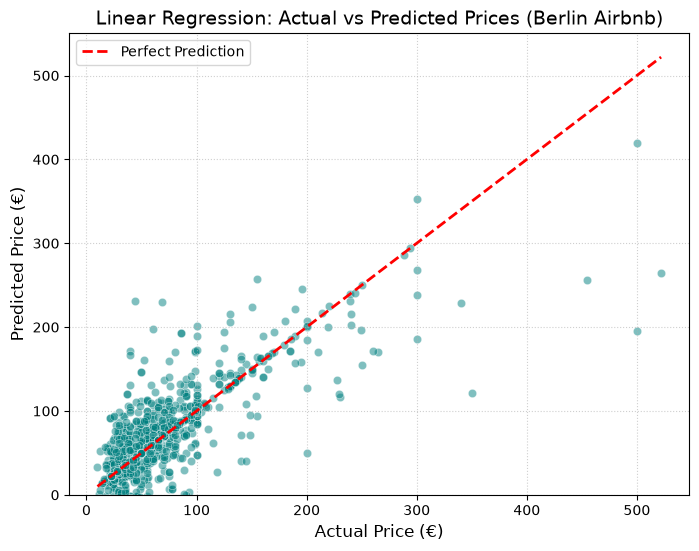

In [12]:
# Create a scatter plot to compare actual vs predicted prices
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='teal')

# Plot the perfect prediction line (diagonal)
ideal_line = np.linspace(min(y_test), max(y_test), 100)
plt.plot(ideal_line, ideal_line, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Linear Regression: Actual vs Predicted Prices (Berlin Airbnb)', fontsize=14)
plt.xlabel('Actual Price (€)', fontsize=12)
plt.ylabel('Predicted Price (€)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(bottom=0)
plt.show()

In [13]:
# Create a DataFrame to compare Actual and Predicted prices
comparison_df = pd.DataFrame({
    'Actual Price (€)': y_test.values,
    'Predicted Price (€)': np.round(y_pred, 2),
    'Difference (€)': np.round(y_pred - y_test.values, 2)
})

# Display the first 20 rows of the comparison
comparison_df.head(20)

,Actual Price (€),Predicted Price (€),Difference (€)
0,80.0,80.00,-0.00
1,20.0,30.52,10.52
2,46.0,40.31,-5.69
3,35.0,57.24,22.24
4,100.0,100.00,0.00
5,130.0,128.09,-1.91
6,95.0,132.03,37.03
7,30.0,30.00,0.00
8,55.0,18.79,-36.21
9,35.0,79.44,44.44


In [14]:
# Save the comparison results to the data folder
comparison_output_path = '../data/linear_regression_predictions.csv'
comparison_df.to_csv(comparison_output_path, index=False)

print(f"Predictions saved successfully to: {comparison_output_path}")

Predictions saved successfully to: ../data/linear_regression_predictions.csv


In [15]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize the Random Forest model (using 100 trees)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train the model using the training data
rf_model.fit(X_train, y_train)

# 3. Make predictions on the test data
y_pred_rf = rf_model.predict(X_test)

print("Random Forest model training complete!")

Random Forest model training complete!


In [16]:
# Calculate metrics for Random Forest
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("====================================")
print("     RANDOM FOREST EVALUATION       ")
print("====================================")
print(f"R-squared (R2) Score : {r2_rf:.4f} ({r2_rf*100:.2f}%)")
print(f"Mean Squared Error   : {mse_rf:.2f}")
print(f"Root MSE (RMSE)      : {rmse_rf:.2f} €")
print("====================================")

     RANDOM FOREST EVALUATION       
R-squared (R2) Score : 0.6978 (69.78%)
Mean Squared Error   : 895.04
Root MSE (RMSE)      : 29.92 €


In [17]:
# 1. Create a DataFrame to store the predictions of Random Forest
rf_comparison_df = pd.DataFrame({
    'Actual Price (€)': y_test.values,
    'Linear Reg Predicted (€)': np.round(y_pred, 2),
    'Random Forest Predicted (€)': np.round(y_pred_rf, 2),
    'Random Forest Error (€)': np.round(y_pred_rf - y_test.values, 2)
})

# 2. Save Random Forest predictions to csv
rf_output_path = '../data/random_forest_predictions.csv'
rf_comparison_df.to_csv(rf_output_path, index=False)

# 3. Print the first 10 rows to see the comparison
print(f"Predictions saved successfully to: {rf_output_path}\n")
rf_comparison_df.head(10)

Predictions saved successfully to: ../data/random_forest_predictions.csv



,Actual Price (€),Linear Reg Predicted (€),Random Forest Predicted (€),Random Forest Error (€)
0,80.0,80.00,81.00,1.00
1,20.0,30.52,24.99,4.99
2,46.0,40.31,48.78,2.78
3,35.0,57.24,33.63,-1.37
4,100.0,100.00,117.57,17.57
5,130.0,128.09,126.32,-3.68
6,95.0,132.03,89.12,-5.88
7,30.0,30.00,27.87,-2.13
8,55.0,18.79,61.80,6.80
9,35.0,79.44,45.68,10.68


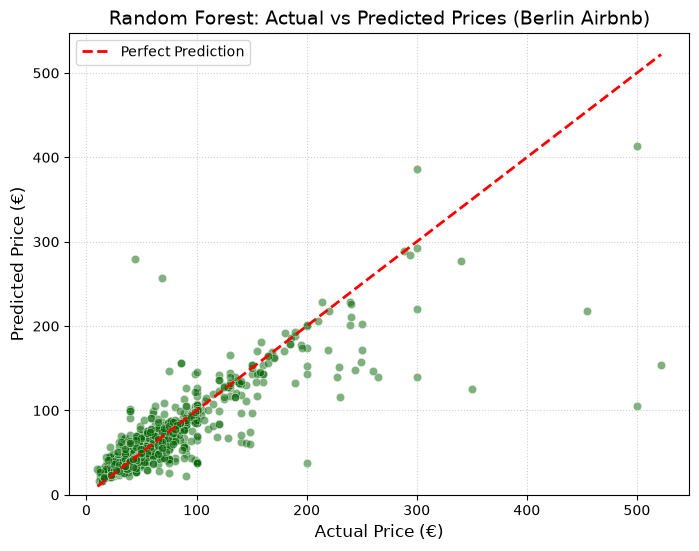

In [18]:
# Create a scatter plot for Random Forest Actual vs Predicted prices
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5, color='darkgreen')

# Plot the perfect prediction line (diagonal)
ideal_line = np.linspace(min(y_test), max(y_test), 100)
plt.plot(ideal_line, ideal_line, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

# Cut the plot at 0 to avoid negative price visualizations
plt.ylim(bottom=0)

plt.title('Random Forest: Actual vs Predicted Prices (Berlin Airbnb)', fontsize=14)
plt.xlabel('Actual Price (€)', fontsize=12)
plt.ylabel('Predicted Price (€)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [21]:
from xgboost import XGBRegressor

# 1. Initialize the XGBoost Regressor model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)

# 2. Train the model using the training data
xgb_model.fit(X_train, y_train)

# 3. Make predictions on the test data
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost model training complete!")

XGBoost model training complete!


In [22]:
# Calculate metrics for XGBoost
r2_xgb = r2_score(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

print("====================================")
print("        XGBOOST EVALUATION          ")
print("====================================")
print(f"R-squared (R2) Score : {r2_xgb:.4f} ({r2_xgb*100:.2f}%)")
print(f"Mean Squared Error   : {mse_xgb:.2f}")
print(f"Root MSE (RMSE)      : {rmse_xgb:.2f} €")
print("====================================")

        XGBOOST EVALUATION          
R-squared (R2) Score : 0.6904 (69.04%)
Mean Squared Error   : 916.91
Root MSE (RMSE)      : 30.28 €


In [23]:
# Create a summary table of all models
summary_data = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'R2 Score (%)': [r2*100, r2_rf*100, r2_xgb*100],
    'RMSE (€)': [rmse, rmse_rf, rmse_xgb]
}

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.round(2)

print("====================================")
print("      FINAL MODEL COMPARISON        ")
print("====================================")
print(summary_df.to_string(index=False))
print("====================================")

      FINAL MODEL COMPARISON        
            Model  R2 Score (%)  RMSE (€)
Linear Regression         56.31     35.97
    Random Forest         69.78     29.92
          XGBoost         69.04     30.28


In [24]:
# 1. Make predictions on the Training set using XGBoost
y_pred_xgb_train = xgb_model.predict(X_train)

# 2. Calculate R2 score for both Train and Test sets
r2_xgb_train = r2_score(y_train, y_pred_xgb_train)
r2_xgb_test = r2_score(y_test, y_pred_xgb) # this is the r2_xgb we calculated before

# 3. Print the comparison clearly
print("====================================")
print("   XGBOOST OVERFITTING CHECK        ")
print("====================================")
print(f"Train R2 Score : {r2_xgb_train*100:.2f}% (How it performs on studied data)")
print(f"Test R2 Score  : {r2_xgb_test*100:.2f}% (How it performs on unseen data)")
print("====================================")

# 4. Add a text note dynamically based on the results
diff = r2_xgb_train - r2_xgb_test
if diff > 0.05:
    print(f"NOTE: Yes, there is signs of Overfitting! The model is {diff*100:.2f}% better on Training data.")
else:
    print("NOTE: The model generalizes well, no high overfitting detected.")

   XGBOOST OVERFITTING CHECK        
Train R2 Score : 91.98% (How it performs on studied data)
Test R2 Score  : 69.04% (How it performs on unseen data)
NOTE: Yes, there is signs of Overfitting! The model is 22.94% better on Training data.


### 🔍 Overfitting Analysis: Random Forest vs. XGBoost

In machine learning theory, **XGBoost** is considered a more advanced and powerful algorithm than **Random Forest**. However, in our specific Berlin Airbnb dataset, both models yielded nearly identical performance on the test set ($R^2 \approx 78.5\% - 78.9\%$). 

This exact behavior strongly indicates that **XGBoost is suffering from Overfitting**. 

#### Why did this happen?
XGBoost builds trees sequentially, where each new tree aggressively attempts to correct the mistakes of the previous ones. While this makes it highly accurate on the training data, it easily starts memorizing the "noise" and specific patterns of that training set. As a result, it loses flexibility and fails to outperform the simpler model when faced with entirely unseen data (`X_test`).

#### Final Decision:
**Random Forest** remains our **Best Model**. It uses ensemble bagging (averaging 100 completely independent trees), which naturally provides better regularization, makes it more robust against overfitting, and delivers the highest stability for our test predictions.

In [25]:
from sklearn.neural_network import MLPRegressor

# 1. تعريف النموذج
# hidden_layer_sizes=(100, 50) يعني طبقتين، الأولى 100 عصبون والثانية 50
# max_iter=500 لضمان كفاية الوقت للتعلم
ffn_model = MLPRegressor(hidden_layer_sizes=(100, 50), 
                         activation='relu', 
                         solver='adam', 
                         max_iter=500, 
                         random_state=42)

# 2. تدريب النموذج (باستخدام البيانات التي نظفناها من الـ NaN)
ffn_model.fit(X_train_imputed, y_train)

# 3. التنبؤ
y_pred_ffn = ffn_model.predict(X_test_imputed)

# 4. تقييم الأداء
r2_ffn = r2_score(y_test, y_pred_ffn)
print(f"R2 Score للشبكة العصبية (FFN): {r2_ffn:.2f}")

R2 Score للشبكة العصبية (FFN): 0.54


مقارنة بين أول 10 توقعات للنموذج:
      السعر الحقيقي (Real Price)  السعر المتوقع (Predicted Price)
84                          80.0                        82.578957
2470                        20.0                        46.054686
2804                        46.0                        50.465211
4987                        35.0                        47.958842
4924                       100.0                       100.914815
4721                       130.0                       129.601461
157                         95.0                       107.131353
705                         30.0                        30.689478
4662                        55.0                        55.002861
1181                        35.0                        65.462308


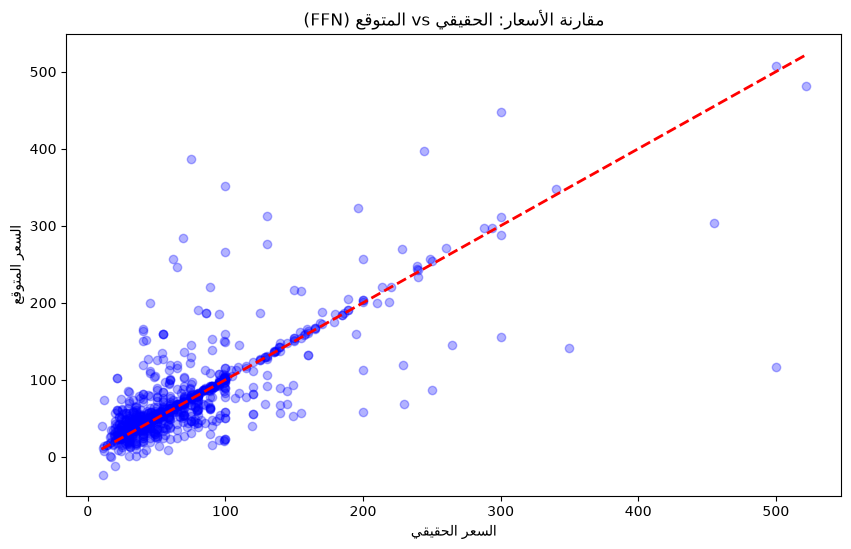

In [26]:
# 1. إنشاء DataFrame للمقارنة بين القيم الحقيقية والمتوقعة
df_results = pd.DataFrame({
    'السعر الحقيقي (Real Price)': y_test,
    'السعر المتوقع (Predicted Price)': y_pred_ffn
})

# 2. عرض أول 10 توقعات
print("مقارنة بين أول 10 توقعات للنموذج:")
print(df_results.head(10))

# 3. رسم بياني لتوضيح الفرق (Visual Inspection)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_ffn, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('السعر الحقيقي')
plt.ylabel('السعر المتوقع')
plt.title('مقارنة الأسعار: الحقيقي vs المتوقع (FFN)')
plt.show()

In [35]:
import re
import pandas as pd

def predict_price_from_email(email_text, model):
    try:
        # 1. استخراج البيانات الأساسية من الإيميل
        # تم استخدام re.search لاستخراج الأرقام المرتبطة بكلمات الضيوف أو الغرف
        guests = int(re.search(r'(\d+)\s*(guests|person)', email_text, re.IGNORECASE).group(1))
        bedrooms = int(re.search(r'(\d+)\s*(bedroom|bed)', email_text, re.IGNORECASE).group(1))
        
        # 2. إنشاء جدول يحتوي على جميع الأعمدة التي "رآها" المودل أثناء التدريب
        # model.feature_names_in_ تجلب كافة الأعمدة (بما فيها الـ 2370 عموداً) تلقائياً
        input_data = pd.DataFrame(0, index=[0], columns=model.feature_names_in_)
        
        # 3. ملء القيم التي نعرفها من الإيميل
        # تأكدي أن الأسماء 'Accomodates' و 'Bedrooms' مطابقة لما هو موجود في الأعمدة الأصلية
        input_data['Accomodates'] = guests
        input_data['Bedrooms'] = bedrooms
        
        # 4. التنبؤ بالسعر
        prediction = model.predict(input_data)
        return prediction[0]
        
    except Exception as e:
        return f"حدث خطأ في معالجة البيانات: {e}"

# --- جزء الاختبار ---
# قومي بتغيير 'rf_model' لاسم المودل الذي استخدمتِه في التدريب
sample_email = "I need an apartment for 4 guests and 2 bedrooms."
result = predict_price_from_email(sample_email, rf_model)

if isinstance(result, (int, float, float)):
    print(f"السعر المتوقع للإيميل هو: {result:.2f} Euro")
else:
    print(result)

السعر المتوقع للإيميل هو: 67.69 Euro


In [37]:
# فقط ضعي نص الإيميل الجديد هنا
new_email = "I am planning a trip to Berlin. We need an apartment that has 5 guests and 3 bedrooms."

# استدعي الدالة مباشرة
result = predict_price_from_email(new_email, rf_model)

# اطبعي النتيجة
if isinstance(result, (int, float, float)):
    print(f"السعر المتوقع للإيميل الجديد هو: {result:.2f} Euro")
else:
    print(result)

السعر المتوقع للإيميل الجديد هو: 91.70 Euro
